In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('Data/staff_turnover_cleaned.csv')
df.head()

,EmpID,Age,Attrition,BusinessTravel,Department,DistanceFromHome,EducationField,EnvironmentSatisfaction,Gender,JobRole,...,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,RM650,53,No,Travel_Rarely,Research & Development,23,Life Sciences,4,Female,Research Director,...,18,3,3,33,0,3,12,9,3,8.0
1,RM015,28,Yes,Travel_Rarely,Research & Development,24,Life Sciences,3,Male,Laboratory Technician,...,14,3,2,6,4,3,4,2,0,3.0
2,RM1111,35,Yes,Travel_Rarely,Research & Development,2,Life Sciences,1,Female,Laboratory Technician,...,12,3,4,1,2,3,1,0,0,0.0
3,RM1438,39,No,Non_Travel,Research & Development,9,Life Sciences,4,Male,Manager,...,13,3,3,21,3,2,6,0,1,3.0
4,RM311,31,No,Travel_Rarely,Human Resources,2,Human Resources,1,Male,Human Resources,...,12,3,4,9,1,3,2,2,1,0.0


In [3]:
df_attrition = df.groupby('Attrition')['EmpID'].count().sort_values(ascending=False).reset_index(name='Cantidad')#.plot(kind='bar', color=['green', 'red'])
df_attrition

,Attrition,Cantidad
0,No,1233
1,Yes,237


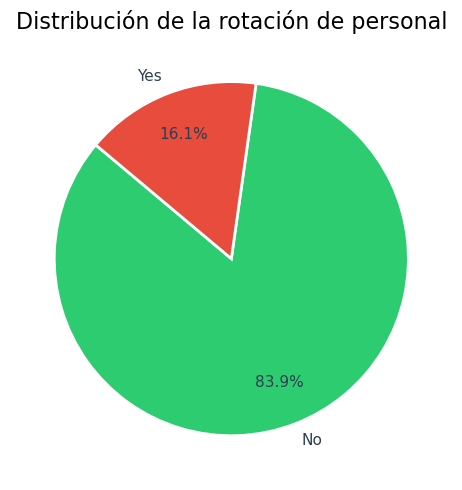

In [4]:
plt.figure(figsize=(6, 5))
colores = ["#2ecc71", "#e74c3c"]

wedges, texts, autotexts = plt.pie(
    df_attrition['Cantidad'],
    labels=df_attrition['Attrition'],
    autopct="%1.1f%%",
    startangle=140,
    colors=colores,
    pctdistance=0.75,
    textprops={"fontsize": 11, "color": "#2C3E50"},
    wedgeprops={"edgecolor": "white", "linewidth": 2}
)

plt.title('Distribución de la rotación de personal', fontsize=16)
plt.tight_layout() 
plt.show()


## 🏠👩🧔**Analysis by Demographic Variables**

* Age
* Education Field
* Gender
* Marital Status



In [5]:
# Agregamos una nueva columna "AgeGroup" al DataFrame para categorizar a los empleados en grupos de edad
df["AgeGroup"] = pd.cut(
    df["Age"], 
    bins=[17, 25, 35, 45, 55, 120], 
    labels=["18-25", "26-35", "36-45", "46-55", "55+"], 
    right=True)

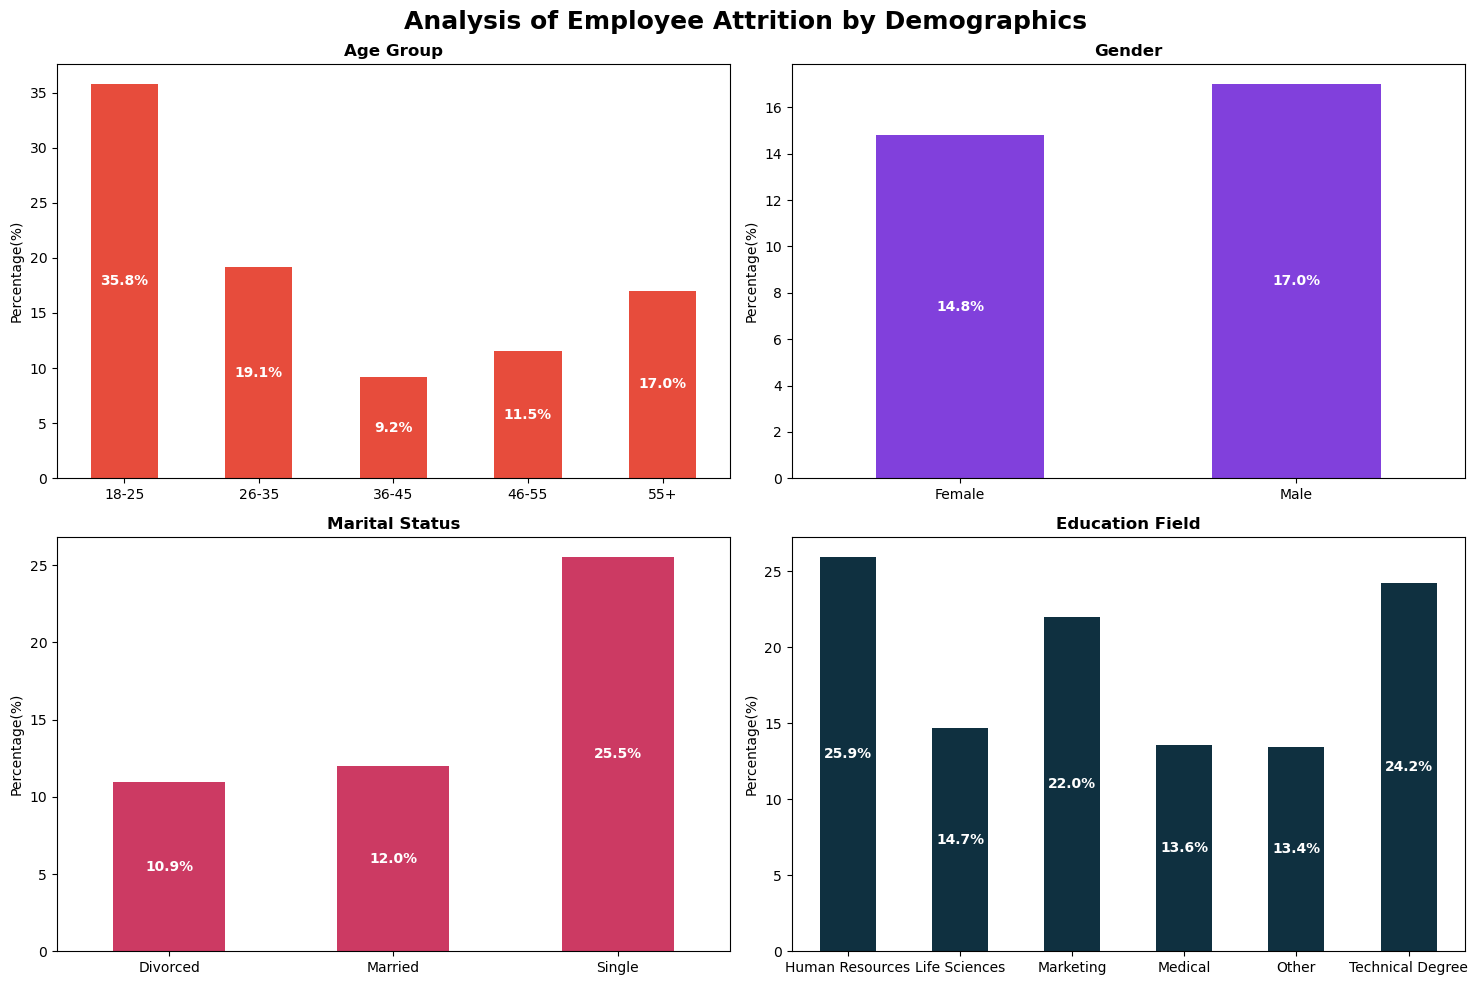

In [6]:
analisis_config = [
    {'columna': 'AgeGroup', 'color': '#e74c3c', 'titulo': 'Age Group'},
    {'columna': 'Gender', 'color': '#8140DC', 'titulo': 'Gender'},
    {'columna': 'MaritalStatus', 'color': '#CC3A63', 'titulo': 'Marital Status'},
    {'columna': 'EducationField', 'color': '#0F3040', 'titulo': 'Education Field'},
   ]

# Crear una cuadrícula de 3 filas y 2 columnas en una sola figura
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(15, 10))
axes = axes.flatten()  # Aplanar la matriz de ejes a una lista simple, transformas esa matriz compleja en una lista lineal de una sola dimensión.

# Bucle para dibujar cada gráfico en su celda correspondiente
for i, config in enumerate(analisis_config):
    ax = axes[i]
    
    # Calcular porcentajes
    df_grouped = df.groupby(config['columna'], observed=False)['Attrition'].value_counts(normalize=True).unstack() * 100
    df_plot = df_grouped[['Yes']]
    
    # Dibujar en el eje específico de la cuadrícula
    df_plot.plot(kind='bar', stacked=True, color=[config['color']], ax=ax, legend=False)
    
    # Etiquetas de porcentaje dentro de las barras
    for contenedor in ax.containers:
        ax.bar_label(contenedor, fmt='%.1f%%', label_type='center', color='white', fontweight='bold', fontsize=10)
    
    # Configuración de textos del subgráfico
    ax.set_title(config['titulo'], fontsize=12, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Percentage(%)')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

# Añadir un título principal a toda la imagen combinada
fig.suptitle('Analysis of Employee Attrition by Demographics', fontsize=18, fontweight='bold', y=0.98)

plt.tight_layout()
plt.show()


In [7]:
# Display the bar chart for Marital Status and Gender vs Attrition
df_MaritalStatus_Gender = df.groupby(['MaritalStatus', 'Gender'])['Attrition'].value_counts(normalize=True).unstack(level='Gender') * 100
df_MaritalStatus_Gender.xs('Yes', level='Attrition')

Gender,Female,Male
MaritalStatus,,
Divorced,9.473684,11.731844
Married,10.544218,12.962963
Single,23.618090,26.937269


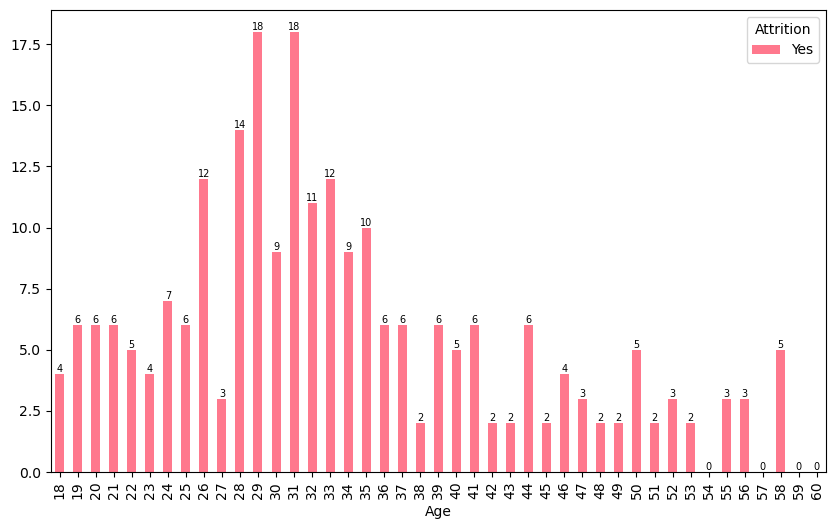

In [8]:
# Display the bar chart for Age vs Attrition
df_Age_attrition = df.groupby(['Age'])['Attrition'].value_counts().unstack()

ax = df_Age_attrition[['Yes']].plot(kind='bar', stacked=True, figsize=(10, 6), color='#FF788D')
ax.bar_label(ax.containers[0], fontsize=7, color='black');

In [12]:
# Display the bar chart for Age and Marital Status vs Attrition
df_MaritalStatus_Age = df.groupby([ 'Age','MaritalStatus'])['Attrition'].value_counts().unstack(level='MaritalStatus')
df_MaritalStatus_Age = df_MaritalStatus_Age.xs('Yes', level='Attrition')

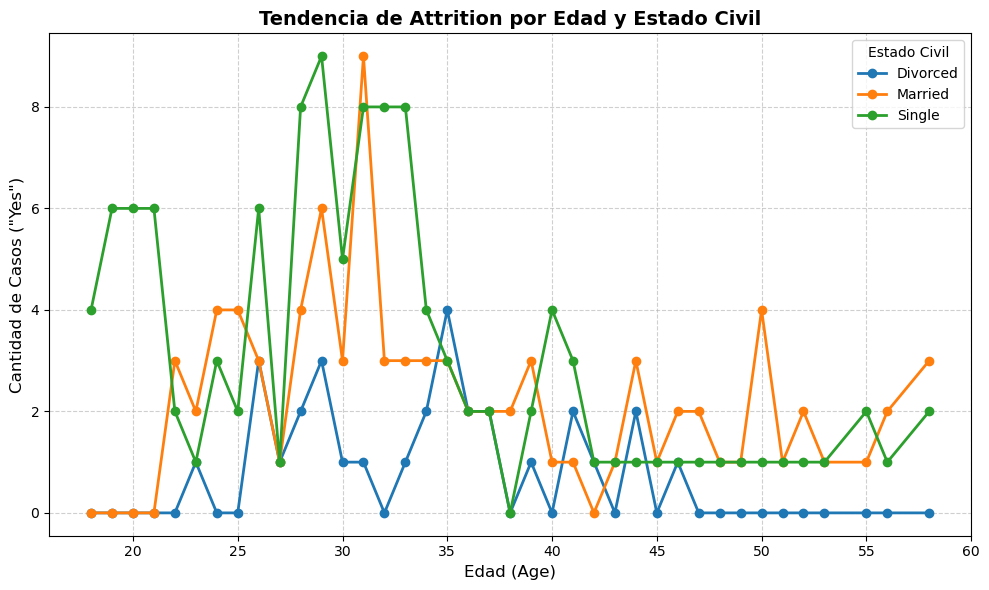

In [14]:
df_lineas = df_MaritalStatus_Age.fillna(0)

df_lineas.plot(kind='line', marker='o', figsize=(10, 6), linewidth=2)

plt.title('Tendencia de Attrition por Edad y Estado Civil', fontsize=14, fontweight='bold')
plt.xlabel('Edad (Age)', fontsize=12)
plt.ylabel('Cantidad de Casos ("Yes")', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)  # Cuadrícula de fondo
plt.legend(title='Estado Civil', fontsize=10)

plt.tight_layout()
plt.show()


Observaciones:

1. Empleados solteros presentan casi el doble de rotación que los empleados casados y divorciados.
2. Hay mas rotación del genero masculino con casi 3 puntos porcentuales por encima del género femenino.
3. Empledos con estudios en área de recursos humanos presentan mayor rotación con casi 26% del total de empleados que dejaron la empresa,  le siguen las personas con algún grado técnico con 24%.
4. El grupo edad de 18 a 25 años presentan casi 39% de rotación, le sigue el grupo edad de 26 a 35 años, disminuye significativamente entre el grupo edad de 36 a 45 años y después vuelve a subir a partir de 46 años.
5. La deserción a la empresa es mayor en edades comprendidas entre los 26 a los 35 años. Hay una tendencia creciente de deserción a medida que nos aproximamos al minimo y máximo del rango de edades estudiado para los solteros.


In [5]:
df_Department_attrition = df.groupby('Department')['Attrition'].value_counts(normalize=True).unstack()
df_Department_attrition = df_Department_attrition[['Yes']].style.format("{:.1%}")
df_Department_attrition

Attrition,Yes
Department,
Human Resources,19.0%
Research & Development,13.8%
Sales,20.6%


In [6]:
df_datos = df.groupby('Department')['Attrition'].value_counts(normalize=True).unstack() * 100
df_datos = df_datos[['Yes']]
df_datos

Attrition,Yes
Department,
Human Resources,19.047619
Research & Development,13.811007
Sales,20.581655


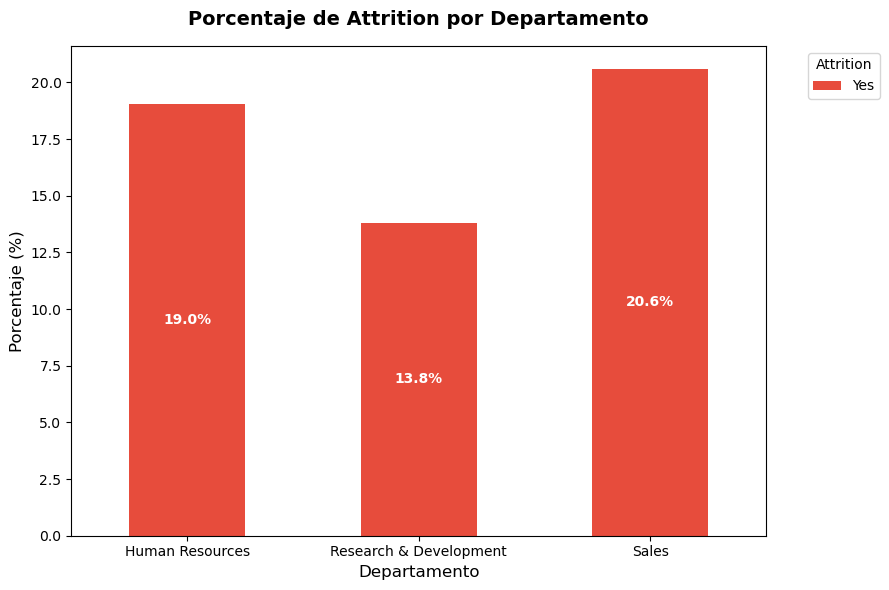

In [7]:
#df_datos = df.groupby('Department')['Attrition'].value_counts(normalize=True).unstack() * 100
df_datos = df.groupby('Department')['Attrition'].value_counts(normalize=True).unstack() * 100
df_datos = df_datos[['Yes']]
ax = df_datos.plot(kind='bar', stacked=True, color=[ '#e74c3c'], figsize=(9, 6))

for contenedor in ax.containers:
    ax.bar_label(contenedor, fmt='%.1f%%', label_type='center', color='white', fontweight='bold', fontsize=10)

plt.title('Porcentaje de Attrition por Departamento', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Departamento', fontsize=12)
plt.ylabel('Porcentaje (%)', fontsize=12)
plt.xticks(rotation=0) 
plt.legend(title='Attrition', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()


## 💸💸💸**Analysis Based on Salary Compensation**

### **Average Income**

In [15]:
MI_df = df.groupby('Attrition')['MonthlyIncome'].agg(['mean', 'median', 'min', 'max'])
MI_df

,mean,median,min,max
Attrition,,,,
No,6832.739659,5204.0,1051,19999
Yes,4787.092827,3202.0,1009,19859


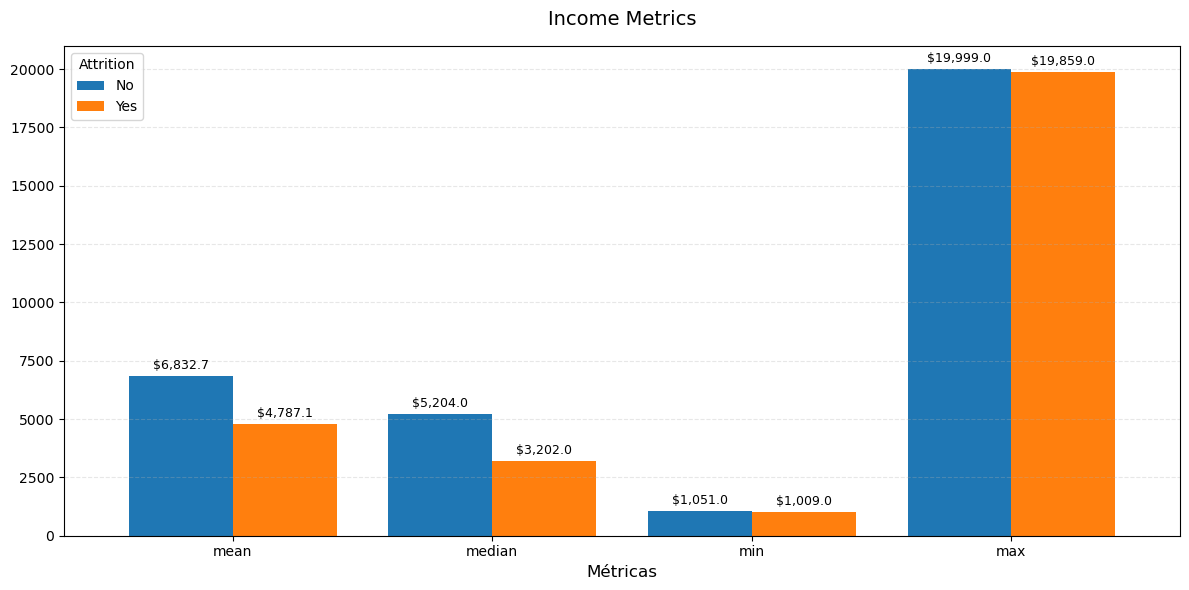

In [16]:
ax = MI_df.T.plot(kind='bar', figsize=(12, 6), width=0.8)

for contenedor in ax.containers:
    etiquetas = [f"${valor:,.1f}" for valor in contenedor.datavalues]
    ax.bar_label(contenedor, labels=etiquetas, padding=3, fontsize=9)
    #ax.bar_label(contenedor, fmt='%.1f', padding=3, fontsize=9)

plt.title('Income Metrics', fontsize=14, pad=15)
plt.xlabel('Métricas', fontsize=12)
#plt.ylabel('Valores', fontsize=12)
plt.xticks(rotation=0)  
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()


The average, mean, minimum, and maximum income of employees who left the company were lower than the income of employees who did not leave.

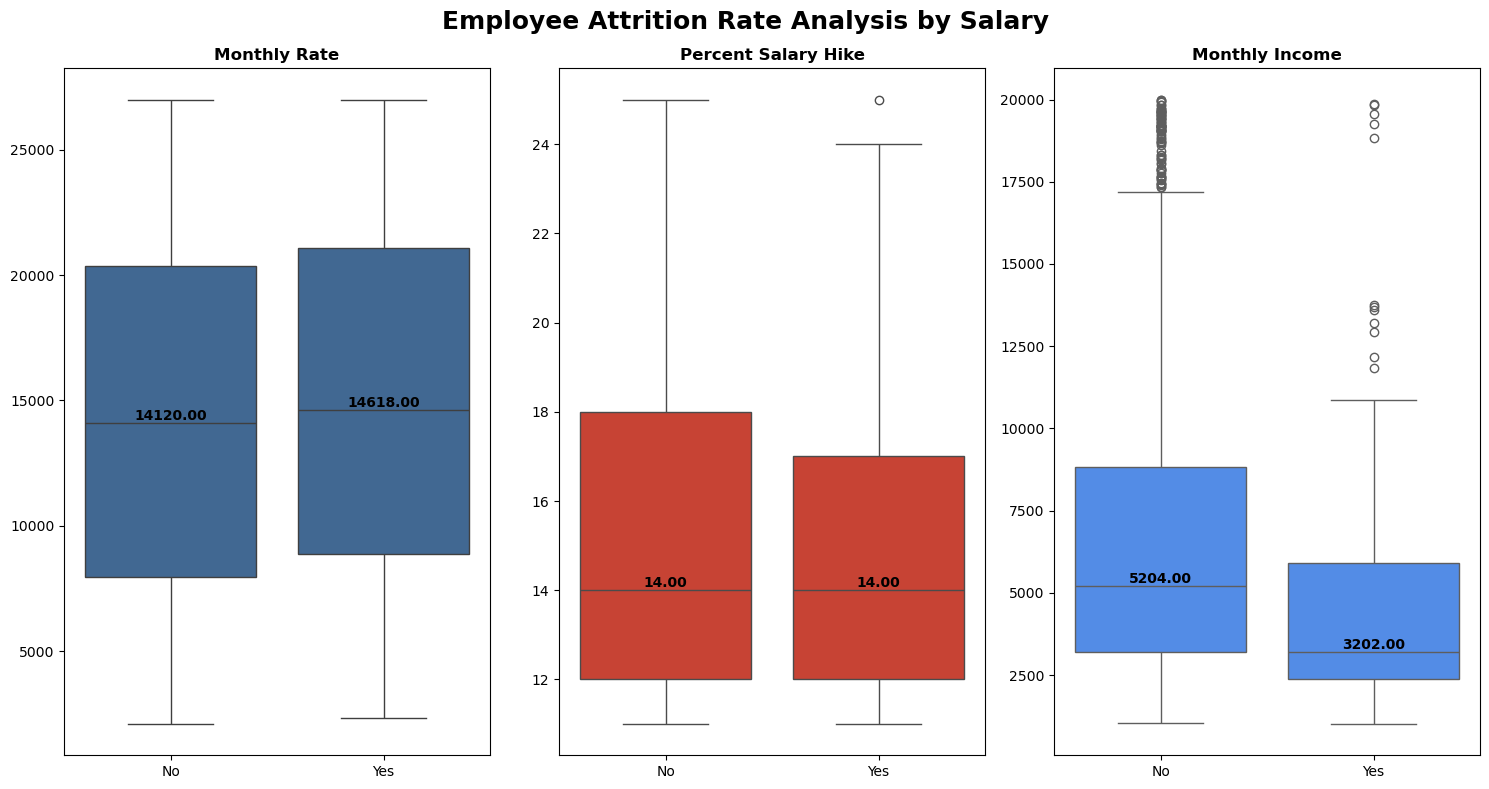

In [19]:
analisis_config = [
    {'columna': 'MonthlyRate', 'color': '#3368A0', 'titulo': 'Monthly Rate'},
    {'columna': 'PercentSalaryHike', 'color': '#DF301C', 'titulo': 'Percent Salary Hike'},
    {'columna': 'MonthlyIncome', 'color': '#3A86FF', 'titulo': 'Monthly Income'},
]

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15, 8))
axes = axes.flatten()  # Aplanar la matriz de ejes a una lista simple, transformas esa matriz compleja en una lista lineal de una sola dimensión.

for i, config in enumerate(analisis_config):
    ax = axes[i]
    
    ax = sns.boxplot(data=df, x='Attrition', y=config['columna'], palette={ 'Yes': config['color'], 'No': config['color']}, hue= 'Attrition', ax=ax)
    medianas = df.groupby(["Attrition"])[config['columna']].median()

    for i, valor in enumerate(medianas):
        ax.text(
            i,  
            valor,  
            f"{valor:.2f}", 
            ha="center", 
            va="bottom", 
            color="black", 
            fontweight="bold", 
        )
 
    ax.set_title(config['titulo'], fontsize=12, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('')
   
fig.suptitle('Employee Attrition Rate Analysis by Salary', fontsize=18, fontweight='bold', y=0.98)

plt.tight_layout()
plt.show()


The "Monthly Rate" indicator is defined as the total monthly cost each employee represents to the organization. A comparison of the distributions reveals a slight upward shift in the group that left the company ("Yes"), with a median of 14,618.00 compared to 14,159.50 for active staff ("No"). This difference of approximately 458 units suggests that the employees who left the company incurred a marginally higher cost; however, the significant overlap between the two groups indicates that the variation is not statistically significant.

## 😊⭐🚩**Analysis by Satisfaction and Atmosphere**

In [20]:
satisfaction_vars = [
    'EnvironmentSatisfaction',
    'JobSatisfaction',
    'RelationshipSatisfaction',
    'WorkLifeBalance']

results = {}

for col in satisfaction_vars:
    # Pocentaje de empleados que dejaron la empresa según cada variable de satisfacción
    results[col] = (df.groupby(col)['Attrition'].apply(lambda x: (x == 'Yes').mean() * 100))

df_satisfaction = pd.DataFrame(results)

df_satisfaction

,EnvironmentSatisfaction,JobSatisfaction,RelationshipSatisfaction,WorkLifeBalance
1,25.352113,22.837370,20.652174,31.250000
2,14.982578,16.428571,14.851485,16.860465
3,13.686534,16.515837,15.468410,14.221725
4,13.452915,11.328976,14.814815,17.647059


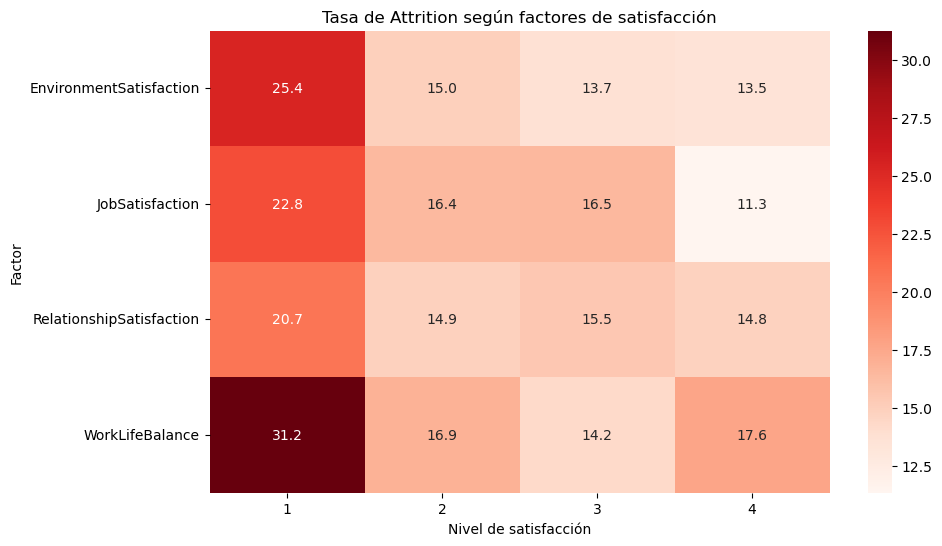

In [21]:
plt.figure(figsize=(10,6))

sns.heatmap(
    df_satisfaction.T,
    annot=True,
    fmt='.1f',
    cmap='Reds'
)

plt.title('Tasa de Attrition según factores de satisfacción')
plt.xlabel('Nivel de satisfacción')
plt.ylabel('Factor')

plt.show()

The heat map reveals that attrition rates reach their highest levels when satisfaction is at its lowest (Level 1). This trend is particularly critical regarding work-life balance, which records the highest rate of staff turnover at 31.2%, followed by satisfaction with the work environment at 25.4%. In contrast, as satisfaction levels rise (levels 2 through 4), attrition rates decrease significantly.

El mapa de calor revela que las tasas de deserción (Attrition) alcanzan sus niveles más altos cuando la satisfacción es mínima (Nivel 1). Este comportamiento es crítico en el factor de balance vida-trabajo (WorkLifeBalance), donde se registra la mayor fuga de personal con un 31.2%, seguido por la satisfacción con el entorno laboral (EnvironmentSatisfaction) que presenta un 25.4%. En contraste, a medida que los niveles de satisfacción aumentan (niveles 2 al 4), los porcentajes de abandono disminuyen de forma notable.

## 💼⏳**Analysis by Seniority and Track Record**

* Total Working Years
* Years At Company
* Years In Current Role
* Years Since Last Promotion
* Num Companies Worked

In [40]:
# Agrupación de los datos por años en la empresa y cálculo del porcentaje de rotación
df['CompanyTenureGroup'] = pd.cut(
    df['YearsAtCompany'],
    bins=[-1, 1, 5, 10, 19, 29, np.inf],
    labels=['0-1','2-5','6-10','11-19','20-29','30+']
)

In [41]:
# Agrupación de los datos por años en el rol actual y cálculo del porcentaje de rotación
df['CurrentRoleTenureGroup'] = pd.cut(
    df['YearsInCurrentRole'],
    bins=[-1, 1, 3, 6, 10, 14, np.inf],
    labels=['0-1','2-3','4-6','7-10','11-14','15+'])

In [42]:
# Nueva columna para agrupar los años desde la última promoción
df['YearsSinceLastPromotionGroup'] = pd.cut(
    df['YearsSinceLastPromotion'],
    bins=[-1, 1, 3, 5, 10, 15, np.inf],
    labels=['0-1', '2-3', '4-5', '6-10', '11-15', '16+']
)

In [43]:
# Nueva columna para agrupar el total de años trabajados
df['TotalWorkingYearsGroup'] = pd.cut(
    df['TotalWorkingYears'],
    bins=[-1, 5, 10, 15, 20, 25, np.inf],
    labels=['0-5', '6-10', '11-15', '16-20', '21-25', '26+'])

In [44]:
# Nueva columna para agrupar el total de compañias en el que ha trabajado el empleado
df['NumberCompaniesWorkedGroup'] = pd.cut(
    df['NumCompaniesWorked'],
    bins=[-1, 1, 2, 3, 4, 5, np.inf],
    labels=['0', '1', '2', '3', '4', '5+'])

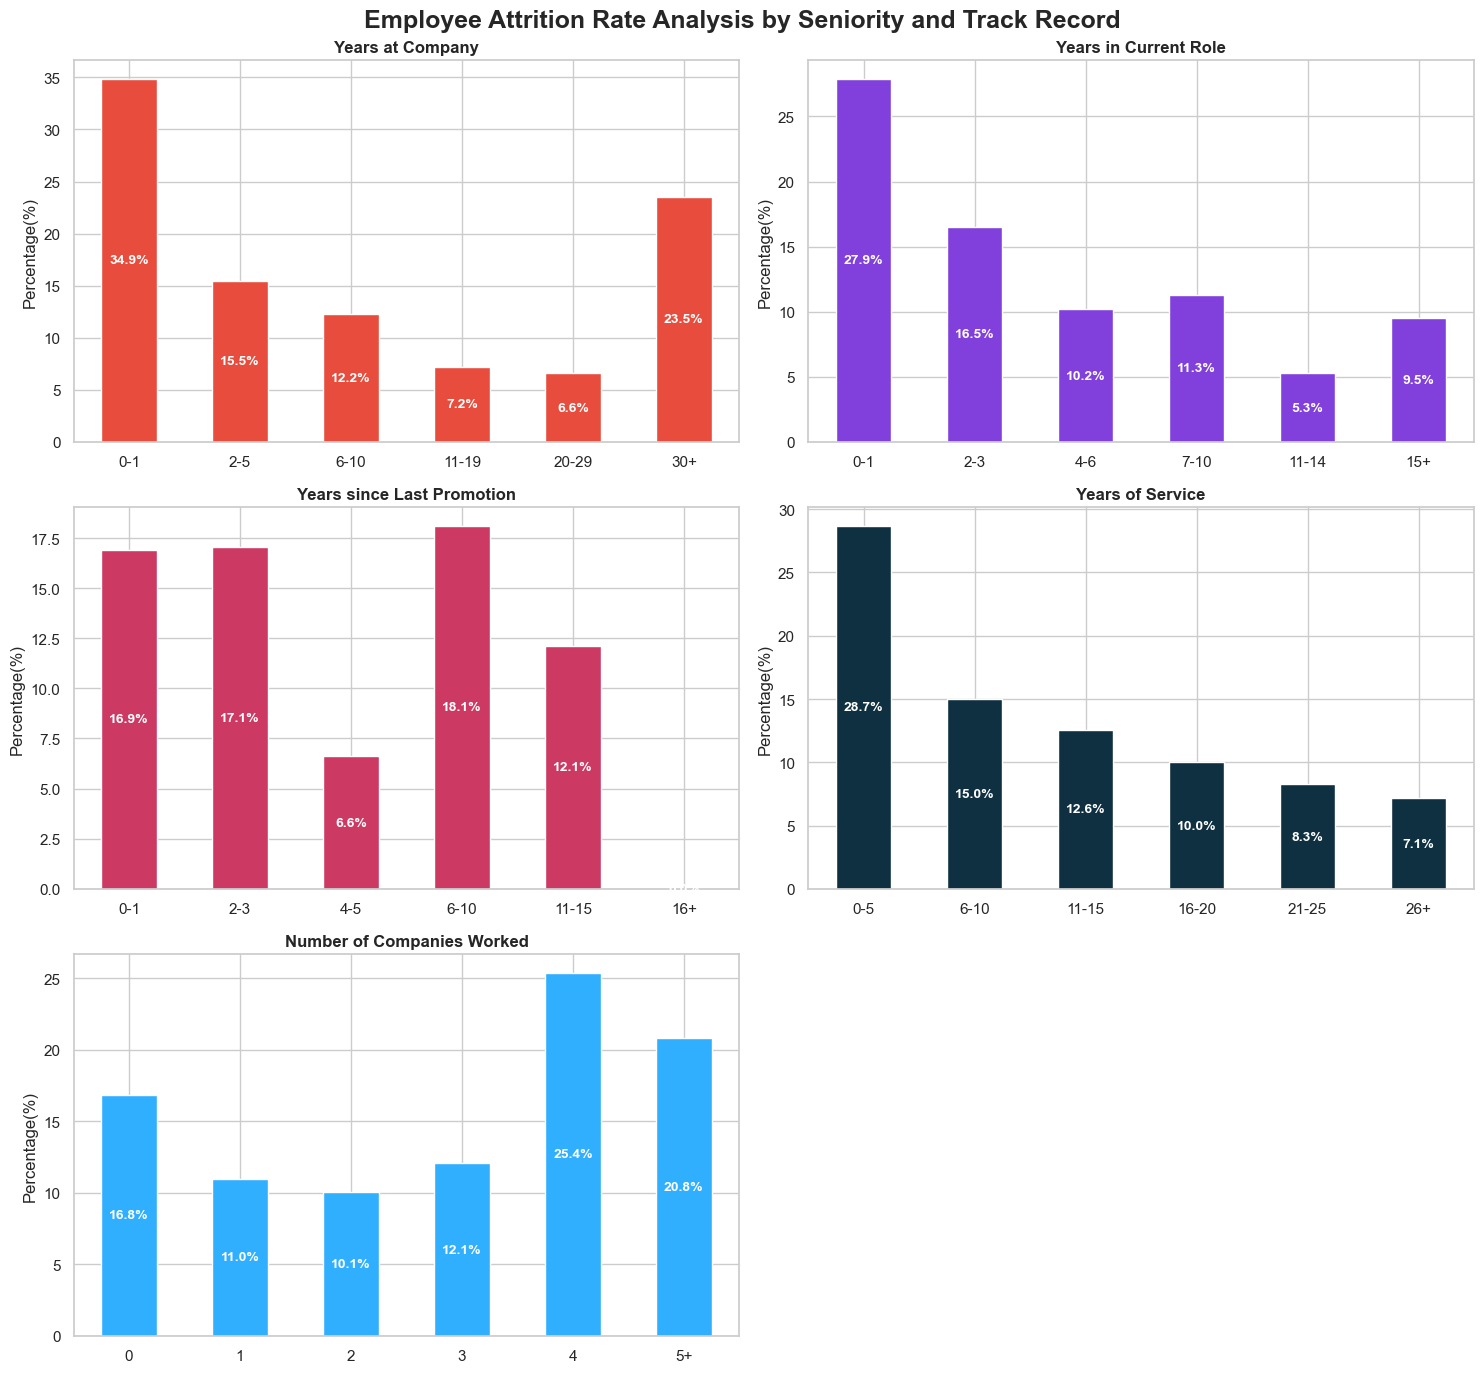

In [45]:
analisis_config = [
    {'columna': 'CompanyTenureGroup', 'color': '#e74c3c', 'titulo': 'Years at Company'},
    {'columna': 'CurrentRoleTenureGroup', 'color': '#8140DC', 'titulo': 'Years in Current Role'},
    {'columna': 'YearsSinceLastPromotionGroup', 'color': '#CC3A63', 'titulo': 'Years since Last Promotion'},
    {'columna': 'TotalWorkingYearsGroup', 'color': '#0F3040', 'titulo': 'Years of Service'},
    {'columna': 'NumberCompaniesWorkedGroup', 'color': '#30AFFF', 'titulo': 'Number of Companies Worked'}
]

# Crear una cuadrícula de 3 filas y 2 columnas en una sola figura
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(15, 14))
axes = axes.flatten()  # Aplanar la matriz de ejes a una lista simple, transformas esa matriz compleja en una lista lineal de una sola dimensión.

# Bucle para dibujar cada gráfico en su celda correspondiente
for i, config in enumerate(analisis_config):
    ax = axes[i]
    
    # Calcular porcentajes
    df_grouped = df.groupby(config['columna'], observed=False)['Attrition'].value_counts(normalize=True).unstack() * 100
    df_plot = df_grouped[['Yes']]
    
    # Dibujar en el eje específico de la cuadrícula
    df_plot.plot(kind='bar', stacked=True, color=[config['color']], ax=ax, legend=False)
    
    # Etiquetas de porcentaje dentro de las barras
    for contenedor in ax.containers:
        ax.bar_label(contenedor, fmt='%.1f%%', label_type='center', color='white', fontweight='bold', fontsize=10)
    
    # Configuración de textos del subgráfico
    ax.set_title(config['titulo'], fontsize=12, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Percentage(%)')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

# Ocultar el sexto subgráfico vacío de la esquina inferior derecha
axes[-1].axis('off')

# Añadir un título principal a toda la imagen combinada
fig.suptitle('Employee Attrition Rate Analysis by Seniority and Track Record', fontsize=18, fontweight='bold', y=0.98)

plt.tight_layout()
plt.show()


In [56]:
# Agrupación de los datos por años en la empresa y años en el rol actual para empleados que dejaron la empresa
df_YearsAtCompany_YearsInCurrentRole_yes = df[df['Attrition'] == 'Yes'][['YearsAtCompany', 'YearsInCurrentRole', 'Attrition']]

In [57]:
# Agrupación de los datos por años en la empresa y años en el rol actual para empleados que dejaron la empresa
df_YearsAtCompany_YearsInCurrentRole_no = df[df['Attrition'] == 'No'][['YearsAtCompany', 'YearsInCurrentRole', 'Attrition']]

In [58]:
# Agrupación de los datos por años en la empresa y años en el rol actual para empleados que dejaron la empresa
df_YearsAtCompany_YearsSinceLastPromotion_Yes = df[df['Attrition'] == 'Yes'][['YearsAtCompany', 'YearsSinceLastPromotion', 'Attrition']]

In [59]:
# Agrupación de los datos por años en la empresa y años en el rol actual para empleados que dejaron la empresa
df_YearsAtCompany_YearsSinceLastPromotion_No = df[df['Attrition'] == 'No'][['YearsAtCompany', 'YearsSinceLastPromotion', 'Attrition']]

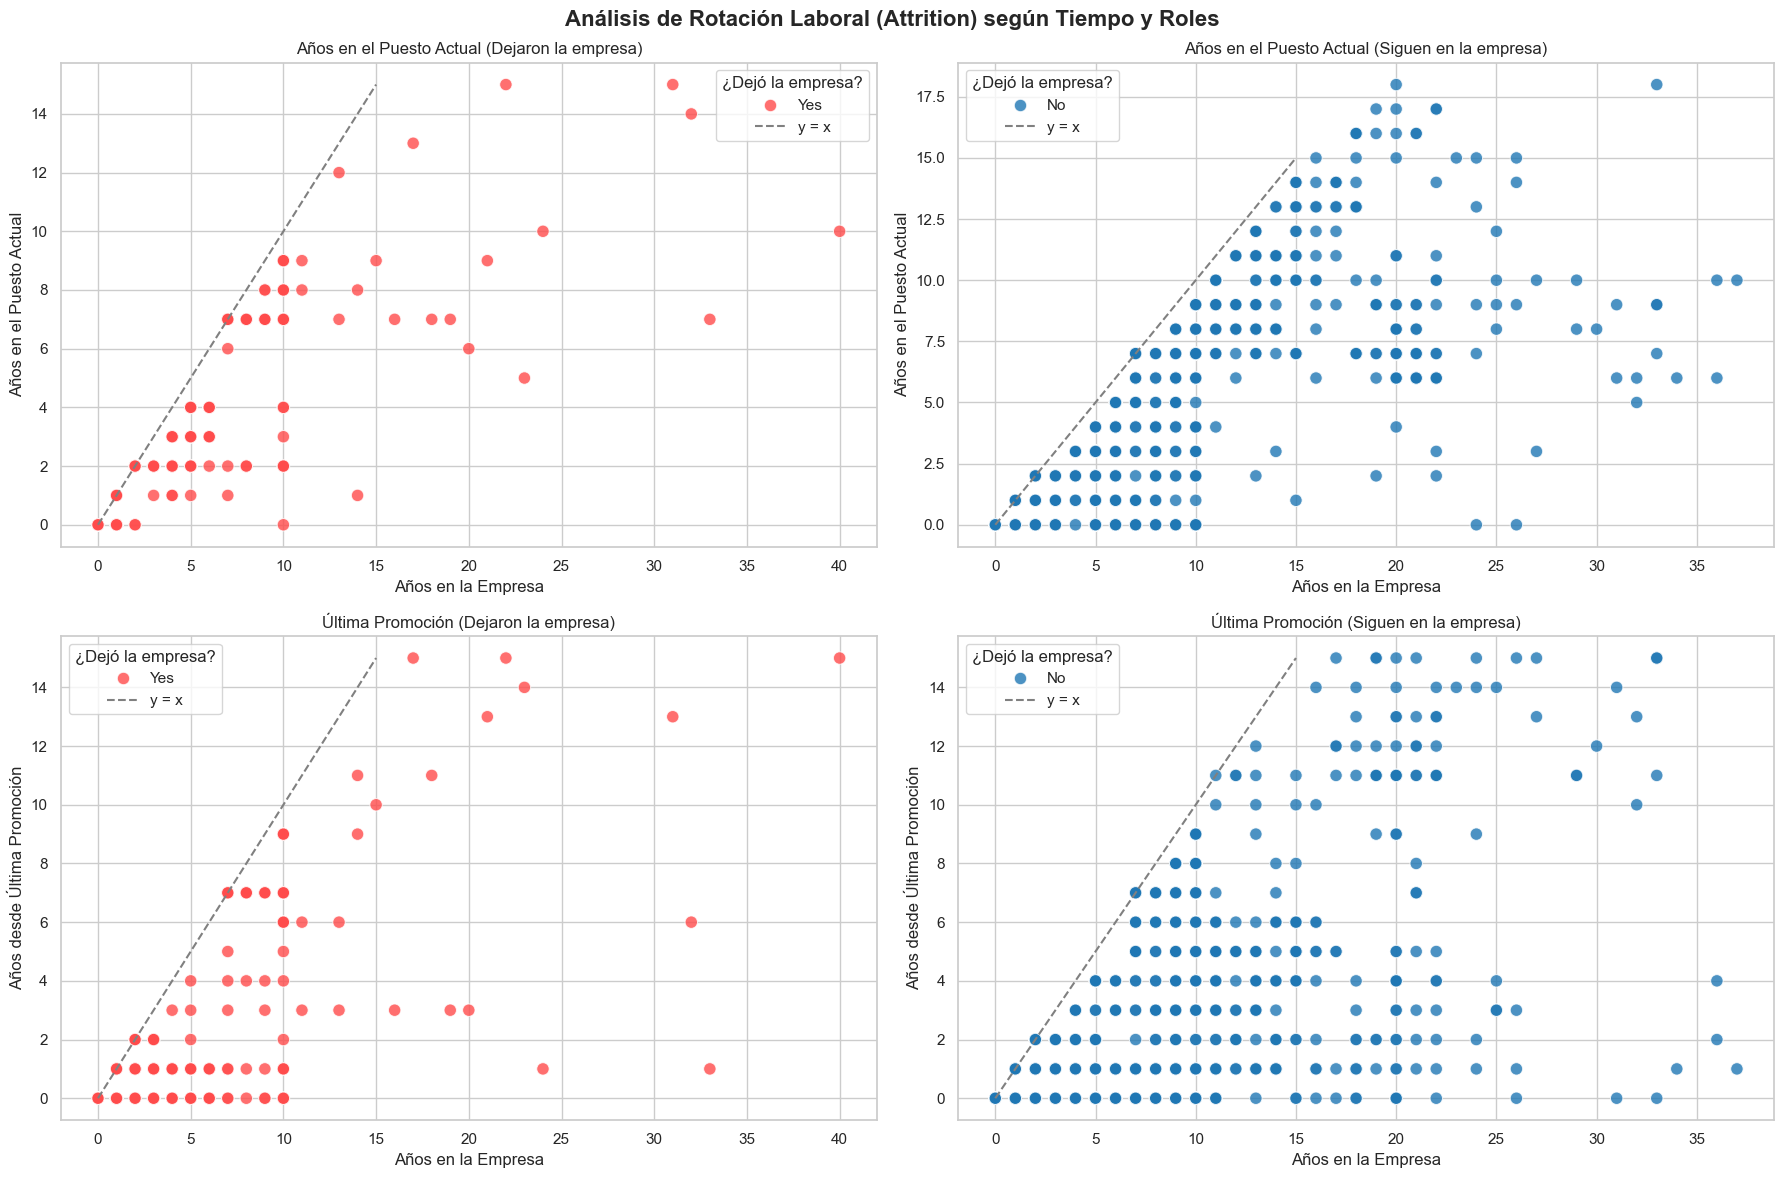

In [60]:
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# --- GRÁFICO 1
sns.scatterplot(
    data=df_YearsAtCompany_YearsInCurrentRole_yes,
    x="YearsAtCompany",
    y="YearsInCurrentRole",
    hue="Attrition",
    palette={"Yes": "#FF4B4B", "No": "#1F77B4"},
    alpha=0.8,
    s=80,
    ax=axes[0, 0],  # Posición fila 0, columna 0
)
axes[0, 0].plot([0, 15], [0, 15], color="gray", linestyle="--", label="y = x")
axes[0, 0].set_title("Años en el Puesto Actual (Dejaron la empresa)")
axes[0, 0].set_xlabel("Años en la Empresa")
axes[0, 0].set_ylabel("Años en el Puesto Actual")
axes[0, 0].legend(title="¿Dejó la empresa?")

# --- GRÁFICO 2 
sns.scatterplot(
    data=df_YearsAtCompany_YearsInCurrentRole_no,
    x="YearsAtCompany",
    y="YearsInCurrentRole",
    hue="Attrition",
    palette={"Yes": "#FF4B4B", "No": "#1F77B4"},
    alpha=0.8,
    s=80,
    ax=axes[0, 1],  # Posición fila 0, columna 1
)
axes[0, 1].plot([0, 15], [0, 15], color="gray", linestyle="--", label="y = x")
axes[0, 1].set_title("Años en el Puesto Actual (Siguen en la empresa)")
axes[0, 1].set_xlabel("Años en la Empresa")
axes[0, 1].set_ylabel("Años en el Puesto Actual")
axes[0, 1].legend(title="¿Dejó la empresa?")

# --- GRÁFICO 3
sns.scatterplot(
    data=df_YearsAtCompany_YearsSinceLastPromotion_Yes,
    x="YearsAtCompany",
    y="YearsSinceLastPromotion",
    hue="Attrition",
    palette={"Yes": "#FF4B4B", "No": "#1F77B4"},
    alpha=0.8,
    s=80,
    ax=axes[1, 0],  # Posición fila 1, columna 0
)
axes[1, 0].plot([0, 15], [0, 15], color="gray", linestyle="--", label="y = x")
axes[1, 0].set_title("Última Promoción (Dejaron la empresa)")
axes[1, 0].set_xlabel("Años en la Empresa")
axes[1, 0].set_ylabel("Años desde Última Promoción")
axes[1, 0].legend(title="¿Dejó la empresa?")

# --- GRÁFICO 4
sns.scatterplot(
    data=df_YearsAtCompany_YearsSinceLastPromotion_No,
    x="YearsAtCompany",
    y="YearsSinceLastPromotion",
    hue="Attrition",
    palette={"Yes": "#FF4B4B", "No": "#1F77B4"},
    alpha=0.8,
    s=80,
    ax=axes[1, 1],  # Posición fila 1, columna 1
)
axes[1, 1].plot([0, 15], [0, 15], color="gray", linestyle="--", label="y = x")
axes[1, 1].set_title("Última Promoción (Siguen en la empresa)")
axes[1, 1].set_xlabel("Años en la Empresa")
axes[1, 1].set_ylabel("Años desde Última Promoción")
axes[1, 1].legend(title="¿Dejó la empresa?")

# 3. Título principal para toda la ventana
fig.suptitle(
    "Análisis de Rotación Laboral (Attrition) según Tiempo y Roles",
    fontsize=16,
    weight="bold",
)

# 4. Ajustar espacios para que no se encima el texto
plt.tight_layout()

# 5. Mostrar la súper gráfica
plt.show()


## 🛠️💼⏳**Analysis by Labor Factors**

* Business Travel
* Over Time
* Distance FromHome
* Num Companies Worked
* Training Times Last Year
* PerformanceRating

1. Is there a higher turnover rate among employees who work overtime?
2. Does the commute distance from home to work influence employee attrition?
3. Is the frequency of business travel related to turnover?
4. Does the number of previous jobs an employee has held influence turnover?
5. How does turnover relate to the time spent on training?

In [65]:
# Agrupación de los datos por distancia desde casa y cálculo del porcentaje de rotación
bins = [-1, 9, 19, np.inf]
labels = ['0-9','10-19','+30']

df['DistanceFromHomeGroup'] = pd.cut(df['DistanceFromHome'], bins=bins, labels=labels)

In [66]:
# Agrupación de los datos por número de compañías trabajadas y cálculo del porcentaje de rotación
bins = [-1, 3, 6, np.inf]
labels = ['0-3','4-6','+7']

df['NumCompaniesWorkedGroup'] = pd.cut(df['NumCompaniesWorked'], bins=bins, labels=labels)

In [67]:
# Agrupación de los datos por número de veces de entrenamiento en el último año y cálculo del porcentaje de rotación
bins = [-1, 1, 3, np.inf]
labels = ['0-1','2-3','+4']

df['TrainingTimesLastYearGroup'] = pd.cut(df['TrainingTimesLastYear'], bins=bins, labels=labels)

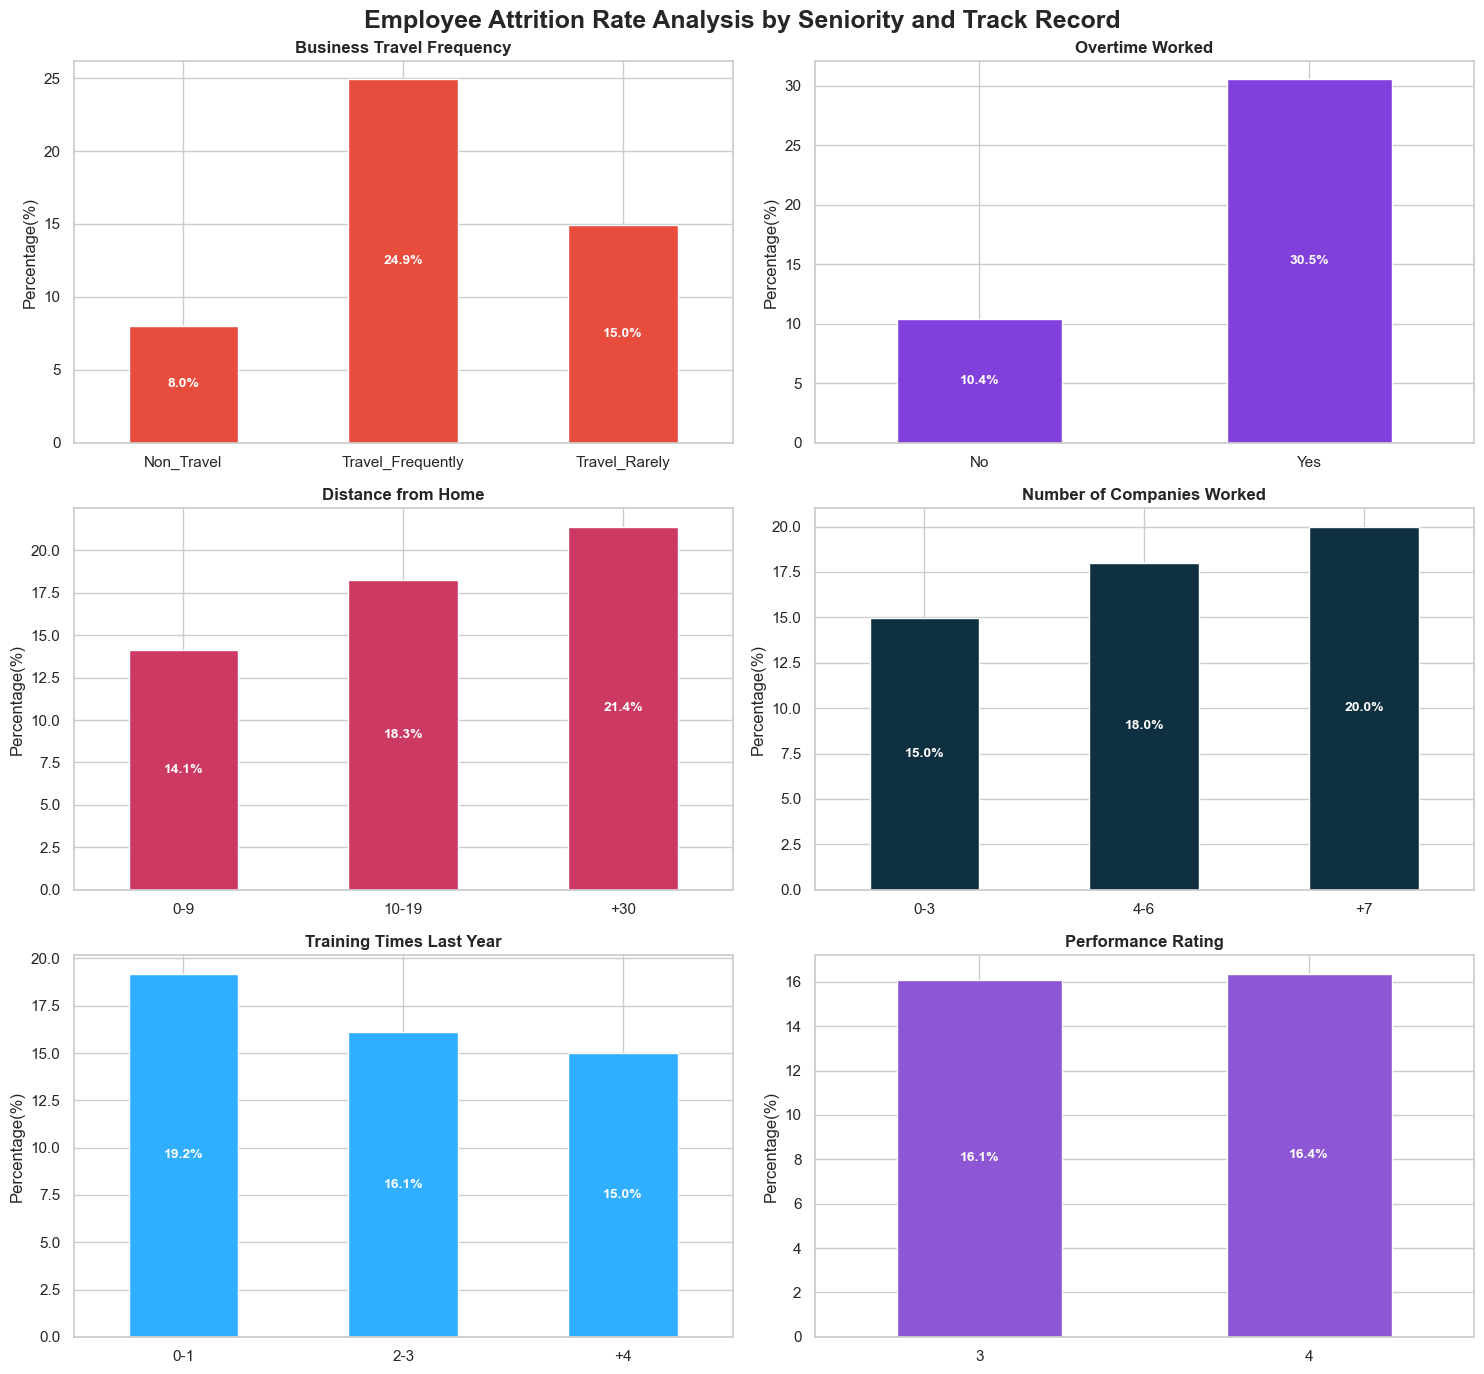

In [69]:
analisis_config = [
    {'columna': 'BusinessTravel', 'color': '#e74c3c', 'titulo': 'Business Travel Frequency'},
    {'columna': 'OverTime', 'color': '#8140DC', 'titulo': 'Overtime Worked'},
    {'columna': 'DistanceFromHomeGroup', 'color': '#CC3A63', 'titulo': 'Distance from Home'},
    {'columna': 'NumCompaniesWorkedGroup', 'color': '#0F3040', 'titulo': 'Number of Companies Worked'},
    {'columna': 'TrainingTimesLastYearGroup', 'color': '#30AFFF', 'titulo': 'Training Times Last Year'},
    {'columna': 'PerformanceRating', 'color': '#8C56D4', 'titulo': 'Performance Rating'}
]

# Crear una cuadrícula de 3 filas y 2 columnas en una sola figura
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(15, 14))
axes = axes.flatten()  # Aplanar la matriz de ejes a una lista simple, transformas esa matriz compleja en una lista lineal de una sola dimensión.

# Bucle para dibujar cada gráfico en su celda correspondiente
for i, config in enumerate(analisis_config):
    ax = axes[i]
    
    # Calcular porcentajes
    df_grouped = df.groupby(config['columna'], observed=False)['Attrition'].value_counts(normalize=True).unstack() * 100
    df_plot = df_grouped[['Yes']]
    
    # Dibujar en el eje específico de la cuadrícula
    df_plot.plot(kind='bar', stacked=True, color=[config['color']], ax=ax, legend=False)
    
    # Etiquetas de porcentaje dentro de las barras
    for contenedor in ax.containers:
        ax.bar_label(contenedor, fmt='%.1f%%', label_type='center', color='white', fontweight='bold', fontsize=10)
    
    # Configuración de textos del subgráfico
    ax.set_title(config['titulo'], fontsize=12, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Percentage(%)')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

# Ocultar el sexto subgráfico vacío de la esquina inferior derecha
#axes[-1].axis('off')

# Añadir un título principal a toda la imagen combinada
fig.suptitle('Employee Attrition Rate Analysis by Seniority and Track Record', fontsize=18, fontweight='bold', y=0.98)

plt.tight_layout()
plt.show()


## XYZ **Análisis multivariable**

In [70]:
df['Attrition_binary'] = (
    df['Attrition'] == 'Yes'
).astype(int)

In [71]:
numeric_cols = df.select_dtypes(
    include='number'
).columns

corr = df[numeric_cols].corr()

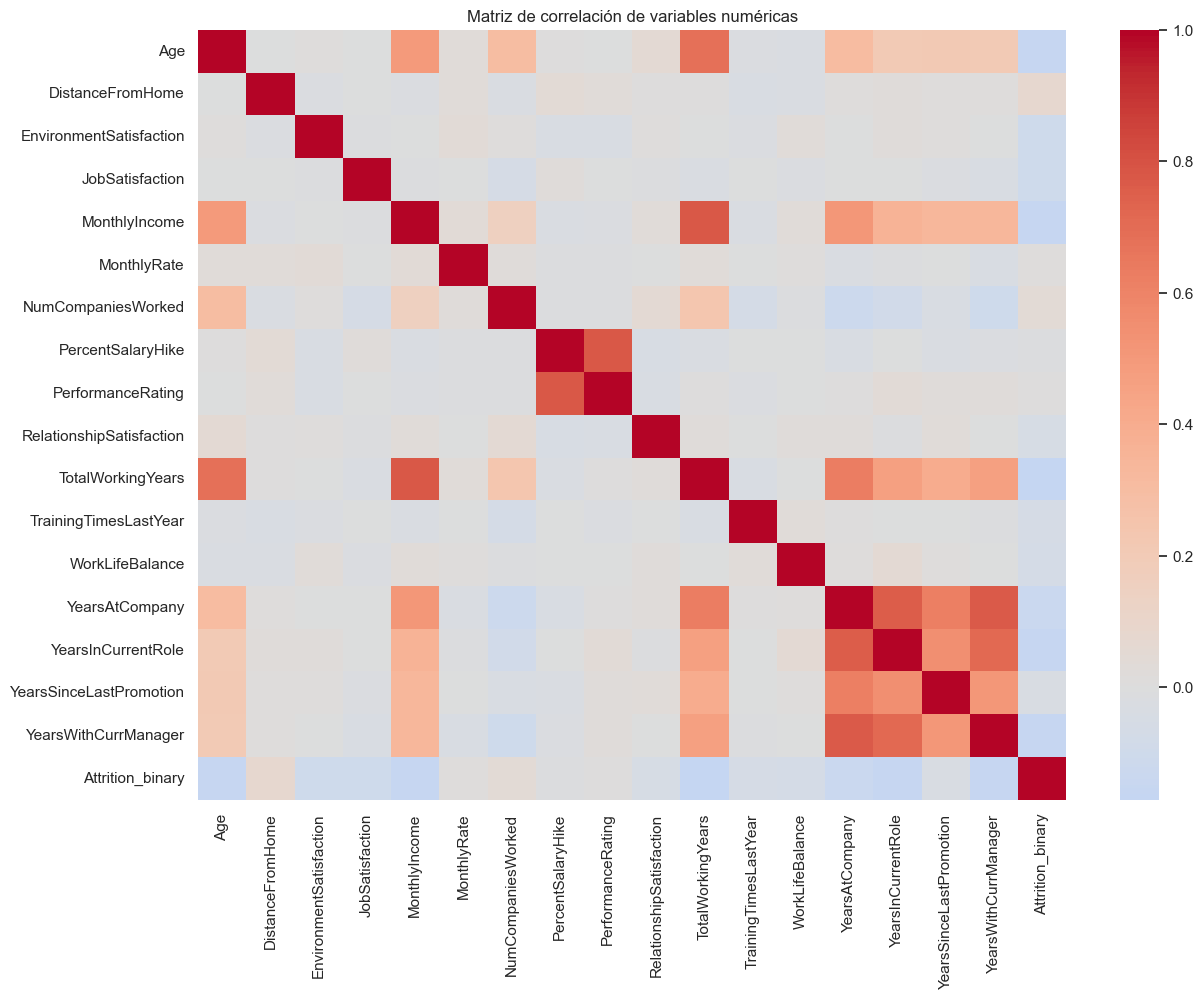

In [72]:
plt.figure(figsize=(14,10))

sns.heatmap(
    corr,
    cmap='coolwarm',
    center=0
)

plt.title('Matriz de correlación de variables numéricas')

plt.show()